In [1]:
import os
import sys
base_directory = os.path.dirname(os.path.abspath(""))
sys.path.append(base_directory)

import matplotlib.pyplot as plt

from radiology_dataset_db.pubmed_utils import search_pubmed, drop_one_analysis, match_pubmed_query
from tests.conftest import _paper_ground_truth

In [2]:
def make_bar_plot(results):
    labels = [r[0] for r in results]
    values = [r[1] for r in results]

    plt.figure(figsize=(10, 8))
    plt.barh(labels, values)  # horizontal is much better for long labels
    plt.xlabel("Number of Results")
    plt.title("Drop-One Analysis of PubMed Query")

    plt.tight_layout()
    plt.show()

# Let's practice analyzing a query.

In [3]:
PUBMED_QUERY = """
("Databases, Factual"[MeSH] OR "Database Management Systems"[MeSH] OR dataset[ti] OR database[ti] OR "data collection"[ti] OR "information repository"[ti] OR benchmark[ti] OR "challenge data"[ti] OR "data commons"[ti] OR "data repository"[ti] OR "data sharing"[ti])
AND ("Radiology"[MeSH] OR "Radiography"[MeSH] OR "Radiology Information Systems"[MeSH] OR radiology[tiab] OR radiograph[tiab] OR "Diagnostic Imaging"[tiab] OR "Medical Image"[tiab] OR "Medical Imaging"[tiab] OR "Biomedical Image"[tiab] OR "Biomedical Imaging"[tiab] OR XR[tiab] OR CT[tiab] OR MRI[tiab] OR PET[tiab] OR SPECT[tiab] OR "X-ray"[tiab] OR "Computed Tomography"[tiab] OR "Magnetic Resonance"[tiab] OR Ultrasound[tiab] OR "Positron Emission Tomography"[tiab] OR "Single Photon Emission Computed Tomography"[tiab])
"""

In [ ]:
results = drop_one_analysis(PUBMED_QUERY)
results

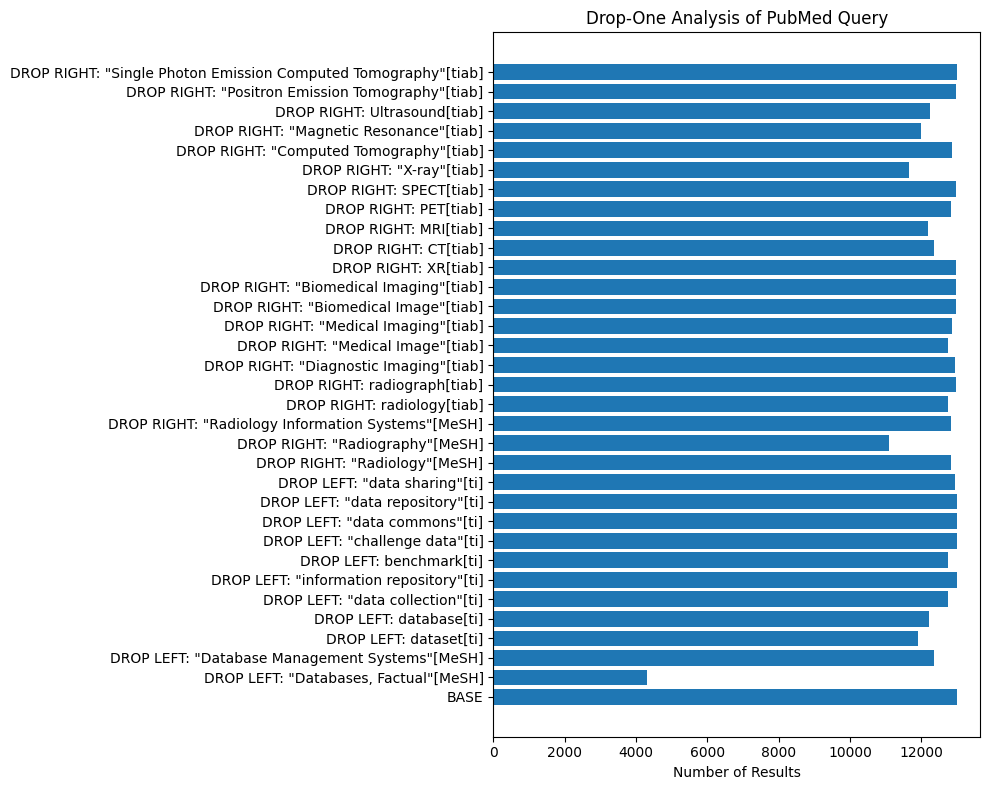

In [ ]:
make_bar_plot(results)

### "Databases, Factual"[MeSH] alone introduces a lot of hits (12988 --> 4316). Let's drop it and retry.

In [ ]:
PUBMED_QUERY = PUBMED_QUERY.replace('"Databases, Factual"[MeSH] OR ', '')
PUBMED_QUERY

'\n("Database Management Systems"[MeSH] OR dataset[ti] OR database[ti] OR "data collection"[ti] OR "information repository"[ti] OR benchmark[ti] OR "challenge data"[ti] OR "data commons"[ti] OR "data repository"[ti] OR "data sharing"[ti])\nAND ("Radiology"[MeSH] OR "Radiography"[MeSH] OR "Radiology Information Systems"[MeSH] OR radiology[tiab] OR radiograph[tiab] OR "Diagnostic Imaging"[tiab] OR "Medical Image"[tiab] OR "Medical Imaging"[tiab] OR "Biomedical Image"[tiab] OR "Biomedical Imaging"[tiab] OR XR[tiab] OR CT[tiab] OR MRI[tiab] OR PET[tiab] OR SPECT[tiab] OR "X-ray"[tiab] OR "Computed Tomography"[tiab] OR "Magnetic Resonance"[tiab] OR Ultrasound[tiab] OR "Positron Emission Tomography"[tiab] OR "Single Photon Emission Computed Tomography"[tiab])\n'

In [ ]:
results = drop_one_analysis(PUBMED_QUERY)
results

[('BASE', 4323),
 ('DROP LEFT: "Database Management Systems"[MeSH]', 3554),
 ('DROP LEFT: dataset[ti]', 3084),
 ('DROP LEFT: database[ti]', 2743),
 ('DROP LEFT: "data collection"[ti]', 4078),
 ('DROP LEFT: "information repository"[ti]', 4322),
 ('DROP LEFT: benchmark[ti]', 4052),
 ('DROP LEFT: "challenge data"[ti]', 4323),
 ('DROP LEFT: "data commons"[ti]', 4318),
 ('DROP LEFT: "data repository"[ti]', 4306),
 ('DROP LEFT: "data sharing"[ti]', 4269),
 ('DROP RIGHT: "Radiology"[MeSH]', 4265),
 ('DROP RIGHT: "Radiography"[MeSH]', 4003),
 ('DROP RIGHT: "Radiology Information Systems"[MeSH]', 4182),
 ('DROP RIGHT: radiology[tiab]', 4220),
 ('DROP RIGHT: radiograph[tiab]', 4314),
 ('DROP RIGHT: "Diagnostic Imaging"[tiab]', 4308),
 ('DROP RIGHT: "Medical Image"[tiab]', 4249),
 ('DROP RIGHT: "Medical Imaging"[tiab]', 4264),
 ('DROP RIGHT: "Biomedical Image"[tiab]', 4313),
 ('DROP RIGHT: "Biomedical Imaging"[tiab]', 4310),
 ('DROP RIGHT: XR[tiab]', 4312),
 ('DROP RIGHT: CT[tiab]', 4069),
 ('DRO

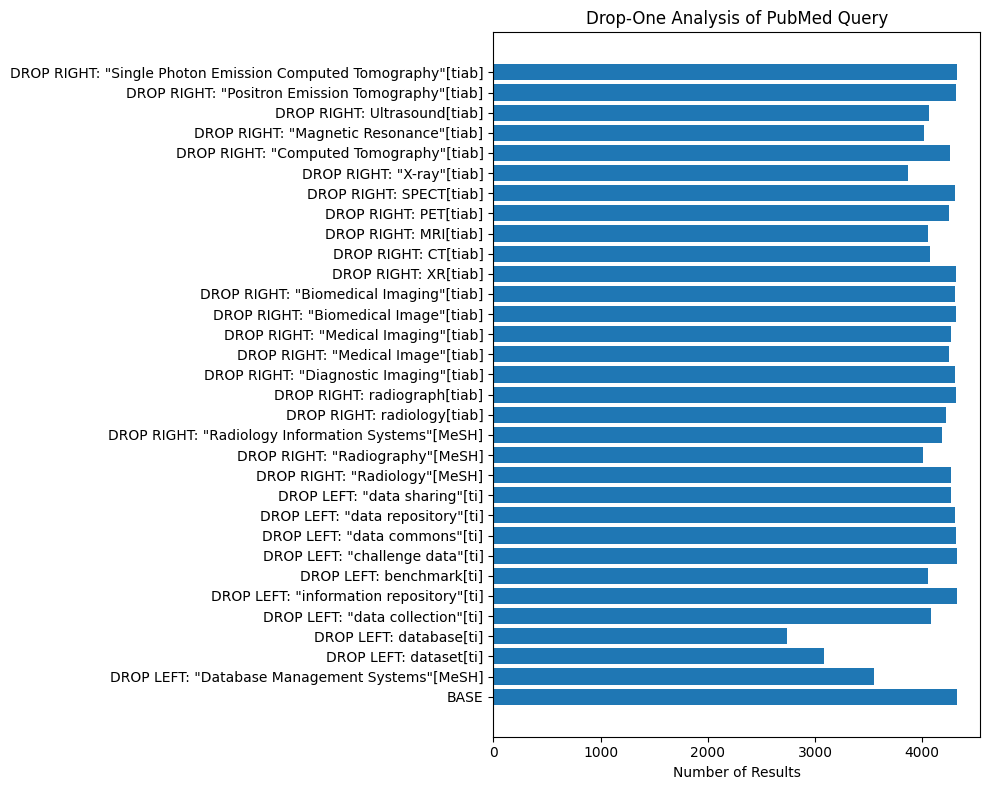

In [ ]:
make_bar_plot(results)

### That's better. Let's look at some of the resulting IDs

In [5]:
PUBMED_QUERY = """
("Database Management Systems"[MeSH] OR dataset[ti] OR database[ti] OR "data collection"[ti] OR "information repository"[ti] OR benchmark[ti] OR "challenge data"[ti] OR "data commons"[ti] OR "data repository"[ti] OR "data sharing"[ti])
AND ("Radiology"[MeSH] OR "Radiography"[MeSH] OR "Radiology Information Systems"[MeSH] OR radiology[tiab] OR radiograph[tiab] OR radiographs[tiab] OR "Diagnostic Imaging"[tiab] OR "Medical Image"[tiab] OR "Medical Imaging"[tiab] OR "Biomedical Image"[tiab] OR "Biomedical Imaging"[tiab] OR XR[tiab] OR CT[tiab] OR MRI[tiab] OR PET[tiab] OR SPECT[tiab] OR "X-ray"[tiab] OR "Computed Tomography"[tiab] OR "Magnetic Resonance"[tiab] OR Ultrasound[tiab] OR "Positron Emission Tomography"[tiab] OR "Single Photon Emission Computed Tomography"[tiab])
NOT (("Nuclear Magnetic Resonance"[tiab] OR NMR[tiab]) OR ("X-ray crystallography"[tiab] OR crystallograph*[tiab] OR diffraction[tiab]) OR (mice[tiab] or mouse[tiab]))
"""
ids = set(search_pubmed(PUBMED_QUERY))

2026-03-29 00:24:29,809 INFO | Searching PubMed...
2026-03-29 00:24:29,811 DEBUG | PubMed query: 
("Database Management Systems"[MeSH] OR dataset[ti] OR database[ti] OR "data collection"[ti] OR "information repository"[ti] OR benchmark[ti] OR "challenge data"[ti] OR "data commons"[ti] OR "data repository"[ti] OR "data sharing"[ti])
AND ("Radiology"[MeSH] OR "Radiography"[MeSH] OR "Radiology Information Systems"[MeSH] OR radiology[tiab] OR radiograph[tiab] OR radiographs[tiab] OR "Diagnostic Imaging"[tiab] OR "Medical Image"[tiab] OR "Medical Imaging"[tiab] OR "Biomedical Image"[tiab] OR "Biomedical Imaging"[tiab] OR XR[tiab] OR CT[tiab] OR MRI[tiab] OR PET[tiab] OR SPECT[tiab] OR "X-ray"[tiab] OR "Computed Tomography"[tiab] OR "Magnetic Resonance"[tiab] OR Ultrasound[tiab] OR "Positron Emission Tomography"[tiab] OR "Single Photon Emission Computed Tomography"[tiab])
NOT (("Nuclear Magnetic Resonance"[tiab] OR NMR[tiab]) OR ("X-ray crystallography"[tiab] OR crystallograph*[tiab] OR diff

In [ ]:
ground_truth_studies = _paper_ground_truth()
for study_key, study_value in ground_truth_studies.items():
    print(f"{study_key}: {study_value['title']}")

radimagenet: RadImageNet: An Open Radiologic Deep Learning Research Dataset for Effective Transfer Learning
mimic_cxr: MIMIC-CXR, a de-identified publicly available database of chest radiographs with free-text reports
uk_biobank: The UK Biobank imaging enhancement of 100,000 participants: rationale, data collection, management and future directions
tcia: The Cancer Imaging Archive (TCIA): Maintaining and Operating a Public Information Repository
merlin: Merlin: a computed tomography vision-language foundation model and dataset
radgenome_chest_ct: Development of a large-scale grounded vision language dataset for chest CT analysis
ct-rate: Generalist foundation models from a multimodal dataset for 3D computed tomography
roco: ROCOv2: Radiology Objects in COntext Version 2, an Updated Multimodal Image Dataset
medmnist_v2: MedMNIST v2: A large-scale lightweight benchmark for 2D and 3D biomedical image classification
idc: National Cancer Institute Imaging Data Commons: Toward Transparency, 

In [ ]:
studies_found = set()
for study_key, study_value in ground_truth_studies.items():
    pmid = study_value.get("pmid")
    if pmid is None:
        print(f"Study {study_value['title']} does not have a PMID, skipping...")
        continue
    study_found = pmid in ids
    print(f"\nStudy {study_value['title']} is in PubMed search results:\n{study_found}")
    if study_found:
        studies_found.add(study_key)
        pubmed_match = match_pubmed_query(query=PUBMED_QUERY, title=study_value['title'], abstract=study_value['abstract'], mesh_terms=None)
        print(f"Pubmed match (without MeSH terms): {pubmed_match}")

print(f"Found {len(studies_found)} out of {len(ground_truth_studies)} studies in PubMed search results.")
print(f"Studies found: {studies_found}")
print(f"Studies not found: {set(ground_truth_studies.keys()) - studies_found}")


Study RadImageNet: An Open Radiologic Deep Learning Research Dataset for Effective Transfer Learning is in PubMed search results:
True
Pubmed match (without MeSH terms): [['dataset[ti]'], ['"Medical Image"[tiab]', 'CT[tiab]', 'MRI[tiab]']]

Study MIMIC-CXR, a de-identified publicly available database of chest radiographs with free-text reports is in PubMed search results:
True
Pubmed match (without MeSH terms): [['database[ti]'], ['radiology[tiab]', 'radiographs[tiab]']]

Study The UK Biobank imaging enhancement of 100,000 participants: rationale, data collection, management and future directions is in PubMed search results:
True
Pubmed match (without MeSH terms): [['"data collection"[ti]'], ['"X-ray"[tiab]', '"Magnetic Resonance"[tiab]', 'Ultrasound[tiab]']]

Study The Cancer Imaging Archive (TCIA): Maintaining and Operating a Public Information Repository is in PubMed search results:
True
Pubmed match (without MeSH terms): [['"information repository"[ti]'], ['"Medical Image"[tiab]',

In [ ]:
!pip list

Package                                  Version         Build Editable project location
---------------------------------------- --------------- ----- -----------------------------------------------
accelerate                               1.13.0
ag-ui-protocol                           0.1.14
aiofile                                  3.9.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
anthropic                                0.86.0
anyio                                    4.12.1
apache-tvm-ffi                           0.1.9
argcomplete                              3.6.3
astor                                    0.8.1
asttokens                                3.0.1
async-timeout                            5.0.1
attrs                                    26.1.0
Authlib                                  1